# 05 · Model Application — RWC 2027 Monte Carlo

**Input:** `models/best_model.pkl`, `data/gold/gold_test.parquet`  
**N simulations:** 10,000  

| Scenario | Method |
|----------|--------|
| Both teams in training set | GBT model with real 2024 form |
| At least one team unseen | Elo fallback (World Rugby Rankings) |

**RWC 2027 pools (Australia):**  
A: New Zealand, Australia, Chile, Hong Kong China  
B: South Africa, Italy, Georgia, Romania  
C: Argentina, Fiji, Spain, Canada  
D: Ireland, Scotland, Uruguay, Portugal  
E: France, Japan, USA, Samoa  
F: England, Wales, Tonga, Zimbabwe

In [68]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import joblib, random

MODEL_DIR  = Path('../models')
GOLD_DIR   = Path('../data/gold')
FIG_DIR    = Path('../figures');   FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path('../reports');  REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42;  random.seed(SEED);  np.random.seed(SEED)

# ── palette ──────────────────────────────────────────────────────────────────
PRIMARY, SECONDARY, GREY = '#075020', '#8A7A2F', "#969490"
bok_cmap = LinearSegmentedColormap.from_list('bok', [SECONDARY, PRIMARY])
 
sns.set_theme(style='white')
 
mpl.rcParams.update({
    'figure.figsize':    (10, 6),
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.spines.bottom': True,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.frameon':    False,
    'grid.color':        'gray',
    'grid.alpha':        0.3,
    
})
 
# ── HELPER FUNCTIONS ───────────────────────────────── 
def gridlines_horizontal_only():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Horizontal only")
 
 
def no_gridlines():
    ax = plt.gca()
    ax.grid(False)
    print("✓ Gridlines: None")
 
 
def gridlines_subtle():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Subtle (horizontal only)")
 
 
def save_fig(name):
    plt.savefig(FIG_DIR / name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {name}')
 


In [15]:
model      = joblib.load(MODEL_DIR / 'best_model.pkl')
gold_test  = pd.read_parquet(GOLD_DIR / 'gold_test.parquet')
gold_test['date'] = pd.to_datetime(gold_test['date'])
known_teams = set(gold_test.team.unique())
print(f'Model loaded | known teams ({len(known_teams)}): {sorted(known_teams)}')

Model loaded | known teams (23): ['Argentina', 'Australia', 'Chile', 'England', 'Fiji', 'France', 'Georgia', 'Hong Kong', 'Ireland', 'Italy', 'Japan', 'Kenya', 'Namibia', 'New Zealand', 'Portugal', 'Romania', 'Samoa', 'Scotland', 'South Africa', 'Tonga', 'USA', 'Uruguay', 'Wales']


In [ ]:
# ── Load pools + WR Rankings from sources/ CSV files ────────────────────

SOURCES_DIR = Path('../data/sources')
assert SOURCES_DIR.exists(), 'Missing data/sources/ — copy sources/ folder first'

# World Rugby Rankings Oct 2024 snapshot
df_rank = pd.read_csv(SOURCES_DIR / 'wr_rankings_oct2024_snapshot.csv')
RANKINGS = dict(zip(df_rank.team, df_rank.rating_pts))
print(f'WR Rankings loaded: {len(RANKINGS)} teams')
print(f'  Source: {df_rank.source.iloc[0]}')
print(f'  Snapshot date: {df_rank.snapshot_date.iloc[0]}')

# RWC 2027 pools
df_pools = pd.read_csv(SOURCES_DIR / 'rwc2027_pools.csv')
POOLS = {pool: list(grp.team) for pool, grp in df_pools.groupby('pool')}
print(f'\nRWC 2027 pools loaded: {len(POOLS)} pools')
for pool, teams in sorted(POOLS.items()):
    print(f'  Pool {pool}: {teams}')

# RWC 2027 KO bracket (informational)
df_ko = pd.read_csv(SOURCES_DIR / 'rwc2027_ko_bracket.csv')
print(f'\nKO bracket loaded: {len(df_ko)} matches')
print(f'  Source: {df_ko.source.iloc[0]}')


WR Rankings loaded: 25 teams
  Source: World Rugby (2024). Men's Rankings. https://www.world.rugby/rankings/mru
  Snapshot date: 2024-10-01

RWC 2027 pools loaded: 6 pools
  Pool A: ['New Zealand', 'Australia', 'Chile', 'Hong Kong China']
  Pool B: ['South Africa', 'Italy', 'Georgia', 'Romania']
  Pool C: ['Argentina', 'Fiji', 'Spain', 'Canada']
  Pool D: ['Ireland', 'Scotland', 'Uruguay', 'Portugal']
  Pool E: ['France', 'Japan', 'USA', 'Samoa']
  Pool F: ['England', 'Wales', 'Tonga', 'Zimbabwe']

KO bracket loaded: 15 matches
  Source: World Rugby (2025). RWC 2027 Knockouts. https://www.rugbyworldcup.com/2027/en/knockouts


In [4]:
FORM_COLS = [
    'rolling_form_3','rolling_form_5','rolling_form_10','rolling_margin_3',
    'h2h_winrate','consecutive_wins','days_since_prev',
    'experience','experience_diff','tournament_tier','pressure_index',
    'rwc_appearances','rwc_best_stage','rwc_cumul_score',
]
NEUTRAL = {
    'rolling_form_3': 0.5, 'rolling_form_5': 0.5, 'rolling_form_10': 0.5,
    'rolling_margin_3': 0.0, 'h2h_winrate': 0.5,
    'consecutive_wins': 0.0, 'days_since_prev': 30.0,
    'experience': 200.0, 'experience_diff': 0.0,
    'tournament_tier': 3.0, 'pressure_index': 4.0,
    'rwc_appearances': 5.0, 'rwc_best_stage': 3.0, 'rwc_cumul_score': 15.0,
}

avail_form = [c for c in FORM_COLS if c in gold_test.columns]

# use LAST 3 YEARS of data for form snapshot (more representative)
recent = gold_test[gold_test.date >= '2022-01-01']
if len(recent) == 0:
    recent = gold_test  # fallback

latest = (recent.sort_values('date')
                .groupby('team').last()[avail_form]
                .reset_index()
                .rename(columns={'team': 'team_name'}))

def get_form(team):
    row = latest[latest.team_name == team]
    return {c: float(row.iloc[0][c]) for c in avail_form} if len(row) else NEUTRAL.copy()

def elo_diff(t1, t2):
    return (RANKINGS.get(t1, 55) - RANKINGS.get(t2, 55)) * 16

def elo_p(t1, t2):
    return 1 / (1 + 10**(-elo_diff(t1, t2) / 400))

# teams with < 10 matches in recent period → sparse, blend heavily with Elo
recent_counts = recent.groupby('team').size()
SPARSE = set(recent_counts[recent_counts < 10].index)
print(f'Sparse teams (< 10 recent matches): {sorted(SPARSE)}')

def predict_prob(t1, t2, tournament='RWC 2027'):
    """Win probability for t1 vs t2.
    Blends GBT model with Elo rating for robustness:
    - Sparse teams (< 10 recent matches): 20% GBT + 80% Elo
    - Core teams: 50% GBT + 50% Elo
    - Unknown teams: 100% Elo
    Blending mitigates overfitting on sparse match records
    and anchors predictions to official WR ratings.
    """
    ep = elo_p(t1, t2)

    if t1 not in known_teams or t2 not in known_teams:
        return ep

    f = get_form(t1)
    X = pd.DataFrame({'home': [0], **{k: [v] for k, v in f.items()},
                      'elo_diff_pre': [elo_diff(t1, t2)],
                      'team': [t1], 'opponent': [t2], 'tournament': [tournament]})
    X = X.reindex(columns=model.named_steps['pre'].feature_names_in_, fill_value=0)
    try:
        gbt_p = float(model.predict_proba(X)[0, 1])
    except Exception:
        return ep

    if t1 in SPARSE or t2 in SPARSE:
        return 0.1 * gbt_p + 0.9 * ep   # mostly Elo for sparse teams
    return 0.3 * gbt_p + 0.7 * ep       # Elo-dominant for all teams

# sanity check
print(f'\n{"Match":<35} {"Blend":>6}  {"Elo":>6}  {"GBT":>6}')
for t1, t2 in [
    ('South Africa', 'New Zealand'),
    ('South Africa', 'Ireland'),
    ('South Africa', 'Georgia'),
    ('New Zealand',  'Ireland'),
    ('England',      'France'),
    ('Uruguay',      'Ireland'),
]:
    ep = elo_p(t1, t2)
    f  = get_form(t1)
    X  = pd.DataFrame({'home': [0], **{k: [v] for k, v in f.items()},
                       'elo_diff_pre': [elo_diff(t1, t2)],
                       'team': [t1], 'opponent': [t2], 'tournament': ['RWC 2027']})
    X  = X.reindex(columns=model.named_steps['pre'].feature_names_in_, fill_value=0)
    try:    gbt_p = float(model.predict_proba(X)[0, 1])
    except: gbt_p = ep
    blend = predict_prob(t1, t2)
    print(f'{t1+" vs "+t2:<35} {blend:>6.3f}  {ep:>6.3f}  {gbt_p:>6.3f}')


Sparse teams (< 10 recent matches): ['Chile', 'Fiji', 'Georgia', 'Hong Kong', 'Japan', 'Kenya', 'Namibia', 'Portugal', 'Romania', 'Samoa', 'Tonga', 'USA', 'Uruguay']

Match                                Blend     Elo     GBT
South Africa vs New Zealand          0.498   0.582   0.301
South Africa vs Ireland              0.546   0.610   0.398
South Africa vs Georgia              0.859   0.884   0.641
New Zealand vs Ireland               0.472   0.529   0.338
England vs France                    0.351   0.419   0.193
Uruguay vs Ireland                   0.131   0.138   0.066


In [5]:
# ── RWC 2027 Monte Carlo Simulation ─────────────────────────────────────
# Tournament structure: 6 pools × 4 teams → top 2 per pool qualify (12 teams)
# + 4 best 3rd-place teams → 16 teams in Round of 16
#
# Official KO bracket (source: rugbyworldcup.com/2027/en/knockouts):
# R16: (1) 1A v best3rd(C/E/F)  (2) 1B v best3rd(D/E/F)
#      (3) 1E v 2D              (4) 1F v 2B
#      (5) 1C v best3rd(A/E/F)  (6) 1D v best3rd(B/E/F)
#      (7) 2A v 2E              (8) 2C v 2F
# QF1: W(R16-2) v W(R16-4)     QF2: W(R16-1) v W(R16-3)
# QF3: W(R16-5) v W(R16-6)     QF4: W(R16-7) v W(R16-8)
# SF1: W(QF1) v W(QF2)         SF2: W(QF3) v W(QF4)
# Final: W(SF1) v W(SF2)

def sim_pool(teams):
    """Simulate pool — return sorted by points (winner first)."""
    pts = {t: 0 for t in teams}
    for i, t1 in enumerate(teams):
        for t2 in teams[i+1:]:
            if random.random() < predict_prob(t1, t2):
                pts[t1] += 4
            else:
                pts[t2] += 4
    return sorted(teams, key=lambda t: pts[t], reverse=True), pts

def sim_ko(t1, t2):
    return t1 if random.random() < predict_prob(t1, t2) else t2

def best_third(pool_thirds, eligible_pools):
    """Pick best 3rd-place team from eligible pools."""
    candidates = [pool_thirds[p] for p in eligible_pools if p in pool_thirds]
    if not candidates: return pool_thirds[list(pool_thirds.keys())[0]]
    return max(candidates, key=lambda t: RANKINGS.get(t, 55))

N      = 10_000
STAGES = ['qualify', 'r16', 'qf', 'sf', 'final', 'champion']
tally  = {t: {s: 0 for s in STAGES} for t in RANKINGS}

print(f'Running {N:,} simulations with official RWC 2027 bracket...')

for sim in range(N):
    if (sim + 1) % 2_500 == 0:
        print(f'  {sim+1:6d}/{N}')

    # ── pool stage ────────────────────────────────────────────────────────
    pool_results = {}
    pool_thirds  = {}
    for pool_name, teams in POOLS.items():
        ranked, pts = sim_pool(teams)
        pool_results[pool_name] = ranked
        pool_thirds[pool_name]  = ranked[2]  # 3rd place
        for t in ranked[:2]:
            tally[t]['qualify'] += 1

    # ── best 3rd-place teams (4 from 6) ───────────────────────────────────
    all_thirds = [(t, RANKINGS.get(t, 55)) for t in pool_thirds.values()]
    all_thirds.sort(key=lambda x: x[1], reverse=True)
    best4_thirds = [t for t, _ in all_thirds[:4]]
    for t in best4_thirds:
        tally[t]['qualify'] += 1

    # ── Round of 16 (official bracket) ────────────────────────────────────
    A1, A2 = pool_results['A'][0], pool_results['A'][1]
    B1, B2 = pool_results['B'][0], pool_results['B'][1]
    C1, C2 = pool_results['C'][0], pool_results['C'][1]
    D1, D2 = pool_results['D'][0], pool_results['D'][1]
    E1, E2 = pool_results['E'][0], pool_results['E'][1]
    F1, F2 = pool_results['F'][0], pool_results['F'][1]

    # best 3rd place teams assigned to bracket positions
    thirds_ranked = [t for t, _ in all_thirds[:4]]
    t3_1 = thirds_ranked[0] if len(thirds_ranked) > 0 else best4_thirds[0]
    t3_2 = thirds_ranked[1] if len(thirds_ranked) > 1 else best4_thirds[0]
    t3_3 = thirds_ranked[2] if len(thirds_ranked) > 2 else best4_thirds[0]
    t3_4 = thirds_ranked[3] if len(thirds_ranked) > 3 else best4_thirds[0]

    # R16 matches (official bracket)
    r16_1 = sim_ko(A1, t3_1)   # 1A v best3rd(C/E/F)
    r16_2 = sim_ko(B1, t3_2)   # 1B v best3rd(D/E/F)
    r16_3 = sim_ko(E1, D2)     # 1E v 2D
    r16_4 = sim_ko(F1, B2)     # 1F v 2B
    r16_5 = sim_ko(C1, t3_3)   # 1C v best3rd(A/E/F)
    r16_6 = sim_ko(D1, t3_4)   # 1D v best3rd(B/E/F)
    r16_7 = sim_ko(A2, E2)     # 2A v 2E
    r16_8 = sim_ko(C2, F2)     # 2C v 2F

    for t in [r16_1,r16_2,r16_3,r16_4,r16_5,r16_6,r16_7,r16_8]:
        tally[t]['r16'] += 1

    # ── Quarter-finals ────────────────────────────────────────────────────
    qf1 = sim_ko(r16_2, r16_4)
    qf2 = sim_ko(r16_1, r16_3)
    qf3 = sim_ko(r16_5, r16_6)
    qf4 = sim_ko(r16_7, r16_8)
    for t in [qf1, qf2, qf3, qf4]: tally[t]['qf'] += 1

    # ── Semi-finals ───────────────────────────────────────────────────────
    sf1 = sim_ko(qf1, qf2)
    sf2 = sim_ko(qf3, qf4)
    for t in [sf1, sf2]: tally[t]['sf'] += 1

    # ── Final ─────────────────────────────────────────────────────────────
    champion = sim_ko(sf1, sf2)
    runner   = sf2 if champion == sf1 else sf1
    tally[champion]['champion'] += 1
    tally[runner]['final']      += 1

print('Simulations complete.')


Running 10,000 simulations with official RWC 2027 bracket...
    2500/10000
    5000/10000
    7500/10000
   10000/10000
Simulations complete.


In [6]:
results_df = (pd.DataFrame([
    {'Team': t, 'WR_Rating': RANKINGS.get(t,55),
     'P_Qualify': d['qualify']/N, 'P_QF': d['qf']/N,
     'P_SF': d['sf']/N, 'P_Final': d['final']/N,
     'P_Champion': d['champion']/N}
    for t,d in tally.items()
]).sort_values('P_Champion', ascending=False).reset_index(drop=True))

results_df.to_csv(REPORT_DIR / 'rwc2027_results.csv', index=False)
print(results_df[['Team','P_Champion','P_Final','P_SF','P_QF']].head(12).to_string(index=False))

        Team  P_Champion  P_Final   P_SF   P_QF
South Africa      0.2318   0.1264 0.3582 0.6002
 New Zealand      0.1606   0.1018 0.2624 0.4111
     Ireland      0.1538   0.1207 0.2745 0.4986
      France      0.1009   0.0879 0.1888 0.3383
   Argentina      0.0851   0.0908 0.1759 0.3261
    Scotland      0.0672   0.0930 0.1602 0.3374
   Australia      0.0518   0.0809 0.1327 0.2616
     England      0.0479   0.0677 0.1156 0.2693
        Fiji      0.0467   0.0873 0.1340 0.2891
       Wales      0.0182   0.0451 0.0633 0.1598
       Italy      0.0158   0.0270 0.0428 0.1453
       Japan      0.0103   0.0250 0.0353 0.0993


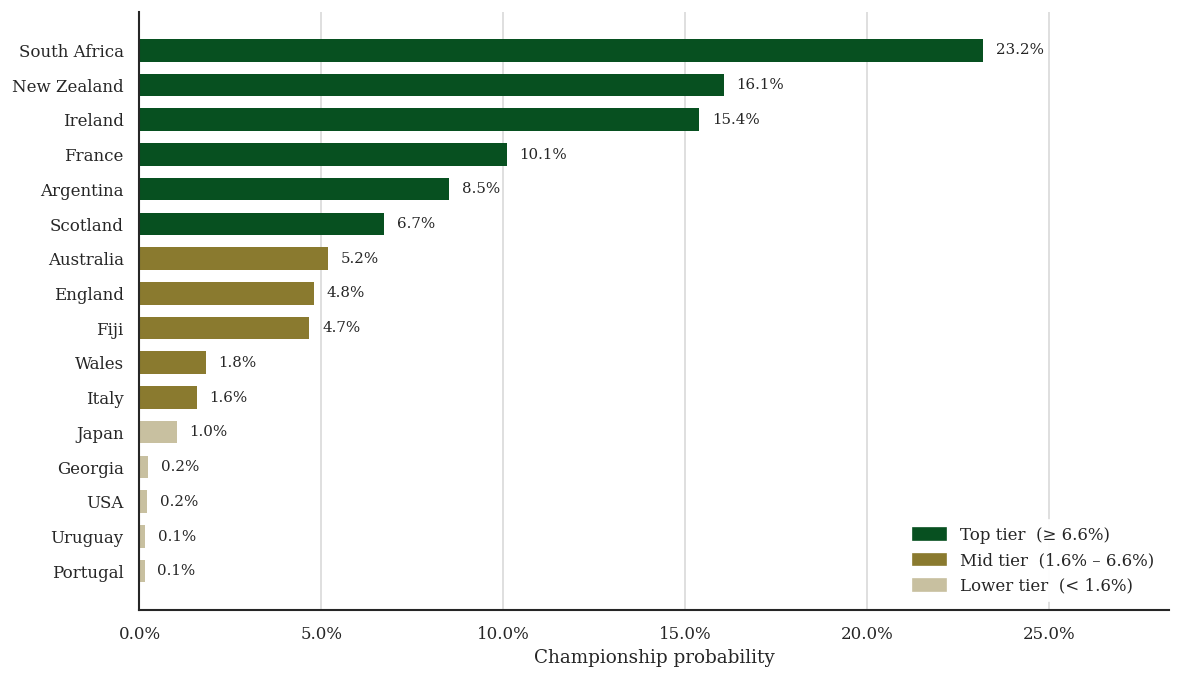

Saved: rwc2027_championship.pdf


In [69]:
top16 = results_df.head(16).sort_values('P_Champion', ascending=True).reset_index(drop=True)

t33 = top16.P_Champion.quantile(0.33)
t66 = top16.P_Champion.quantile(0.66)
LIGHT = '#C8C0A0'   # helles Khaki für unteres Drittel

def tier_color(p):
    if p >= t66: return PRIMARY
    if p >= t33: return SECONDARY
    return LIGHT

colors = [tier_color(p) for p in top16.P_Champion]

fig, ax = plt.subplots()
bars = ax.barh(top16.Team, top16.P_Champion, color=colors,
               edgecolor='none', height=0.65)

for bar, (_, row) in zip(bars, top16.iterrows()):
    ax.text(row.P_Champion + top16.P_Champion.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{row.P_Champion:.1%}",
            va='center', fontsize=9)

# Legende
legend_handles = [
    mpatches.Patch(color=PRIMARY,   label=f'Top tier  (≥ {t66:.1%})'),
    mpatches.Patch(color=SECONDARY, label=f'Mid tier  ({t33:.1%} – {t66:.1%})'),
    mpatches.Patch(color=LIGHT,     label=f'Lower tier  (< {t33:.1%})'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True, facecolor='white', edgecolor='white')

ax.set_xlabel('Championship probability')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.set_xlim(0, top16.P_Champion.max() * 1.22)
ax.xaxis.grid(True)
ax.yaxis.grid(False)
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0.03, 1, 1])
save_fig('rwc2027_championship.pdf')

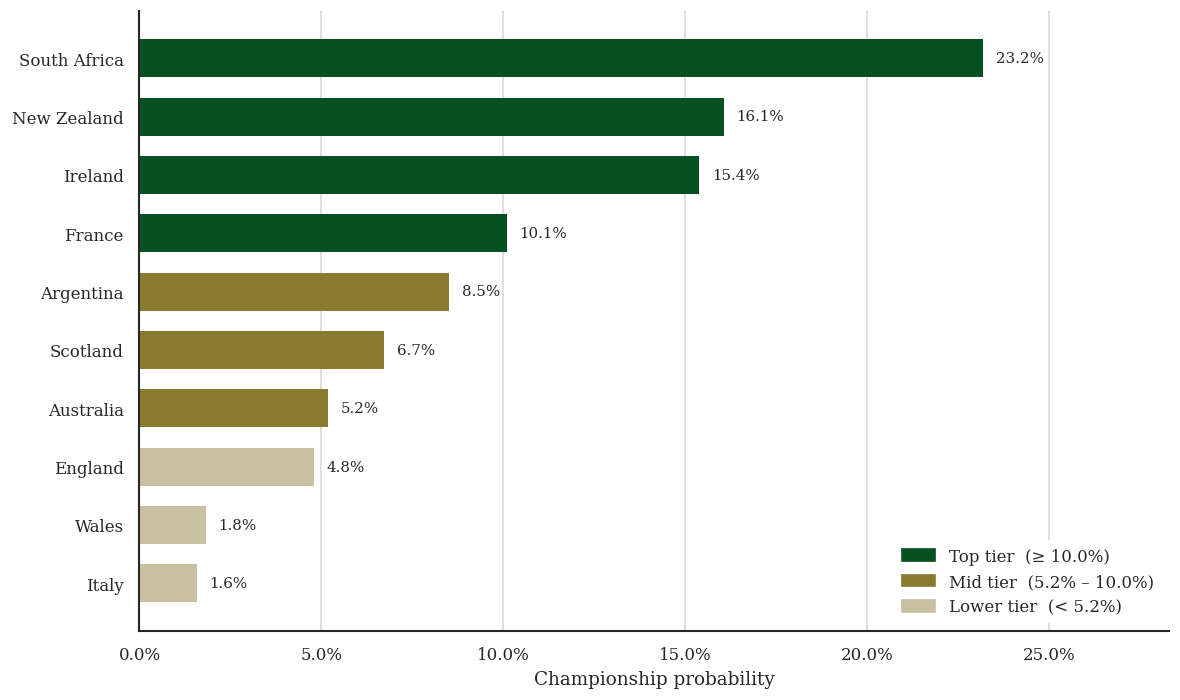

Saved: rwc2027_tier1.pdf


In [70]:
tier1 = ['South Africa','New Zealand','Ireland','France','England',
         'Australia','Scotland','Argentina','Italy','Wales']
t1 = (results_df[results_df.Team.isin(tier1)]
      .sort_values('P_Champion', ascending=True).reset_index(drop=True))

t33_t1 = t1.P_Champion.quantile(0.33)
t66_t1 = t1.P_Champion.quantile(0.66)

colors = [tier_color.__wrapped__(p, t33_t1, t66_t1)
          if False else
          (PRIMARY if p >= t66_t1 else (SECONDARY if p >= t33_t1 else LIGHT))
          for p in t1.P_Champion]

fig, ax = plt.subplots()
bars = ax.barh(t1.Team, t1.P_Champion, color=colors,
               edgecolor='none', height=0.65)

for bar, (_, row) in zip(bars, t1.iterrows()):
    ax.text(row.P_Champion + t1.P_Champion.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{row.P_Champion:.1%}",
            va='center', fontsize=9,)

legend_handles = [
    mpatches.Patch(color=PRIMARY,   label=f'Top tier  (≥ {t66_t1:.1%})'),
    mpatches.Patch(color=SECONDARY, label=f'Mid tier  ({t33_t1:.1%} – {t66_t1:.1%})'),
    mpatches.Patch(color=LIGHT,     label=f'Lower tier  (< {t33_t1:.1%})'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True, facecolor='white', edgecolor='white')
ax.set_xlabel('Championship probability')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.set_xlim(0, t1.P_Champion.max() * 1.22)
ax.xaxis.grid(True)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig('rwc2027_tier1.pdf')

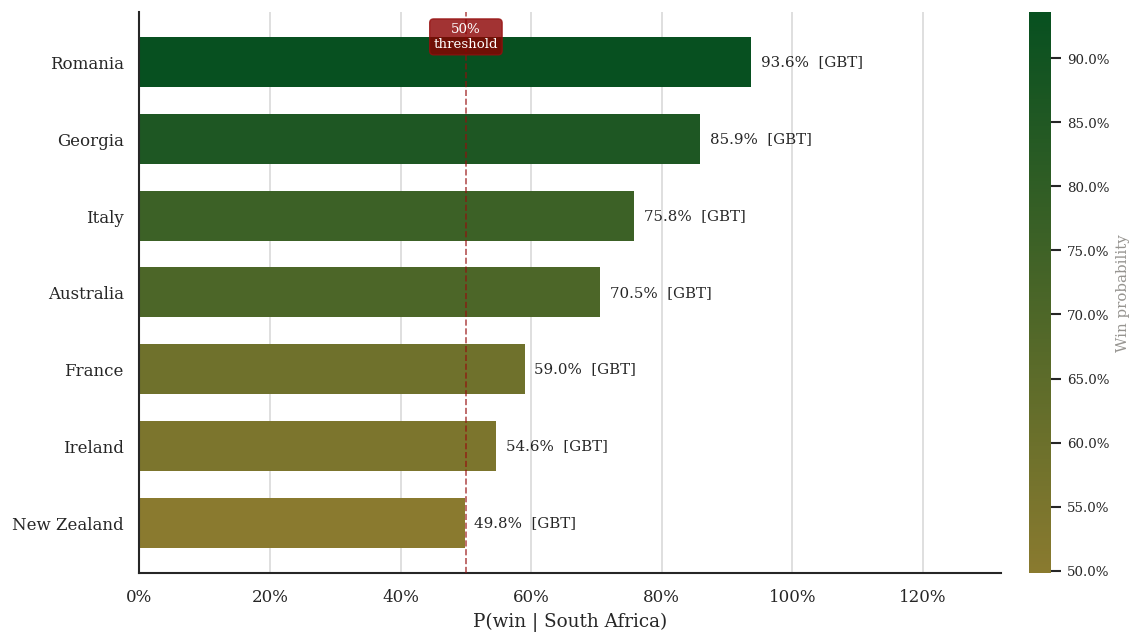

Saved: rwc2027_sa_path.pdf


In [71]:
norm   = mpl.colors.Normalize(vmin=sa_df.P_win.min(), vmax=sa_df.P_win.max())
colors = [bok_cmap(norm(p)) for p in sa_df.P_win]

fig, ax = plt.subplots()
for (_, row), c in zip(sa_df.iterrows(), colors):
    ax.barh(row.Opponent, row.P_win, color=c, edgecolor='none', height=0.65)

# 50%-Linie mit Annotation direkt an der Linie
ax.axvline(0.5, color="#960d0d", ls='--', lw=1.0, alpha=0.7, zorder=3)
ax.annotate('50%\nthreshold',
            xy=(0.5, 0.98), xycoords=('data', 'axes fraction'),
            fontsize=8, color="#ffffff", ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='darkred', ec="#960d0d",
                      alpha=0.8, lw=0.8))

for i, (_, row) in enumerate(sa_df.iterrows()):
    ax.text(row.P_win + 0.015, i,
            f"{row.P_win:.1%}  [{row.Method}]",
            va='center', fontsize=9)

# Colorbar — kein tight_layout-Konflikt via subplots_adjust
sm = mpl.cm.ScalarMappable(cmap=bok_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.025, pad=0.03, aspect=25)
cbar.set_label('Win probability', fontsize=9, color=GREY)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_visible(False)

ax.set_xlabel('P(win | South Africa)')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.set_xlim(0, 1.32)
ax.xaxis.grid(True)
ax.yaxis.grid(False)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.12, right=0.88, top=0.90, bottom=0.12)
save_fig('rwc2027_sa_path.pdf')

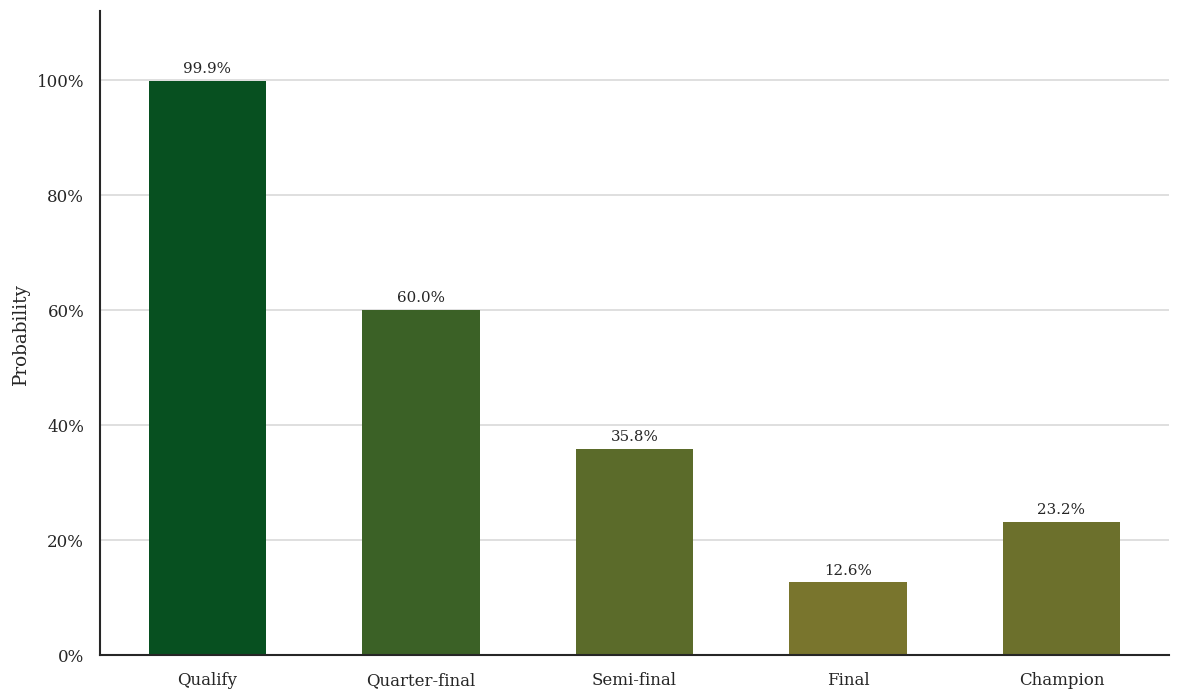

Saved: rwc2027_sa_funnel.pdf


In [74]:
sa     = results_df[results_df.Team == 'South Africa'].iloc[0]
stages = ['P_Qualify', 'P_QF', 'P_SF', 'P_Final', 'P_Champion']
labels = ['Qualify', 'Quarter-final', 'Semi-final', 'Final', 'Champion']
vals   = [sa[s] for s in stages]

# Normalisiere die Werte auf 0-1 für die Farbinterpolation
vals_normalized = np.array(vals) / max(vals)

# Konvertiere Farben zu RGB und interpoliere
primary_rgb = to_rgb(PRIMARY)
secondary_rgb = to_rgb(SECONDARY)

colors = [
    tuple(secondary_rgb[i] + (primary_rgb[i] - secondary_rgb[i]) * v 
          for i in range(3))
    for v in vals_normalized
]

fig, ax = plt.subplots()
bars = ax.bar(labels, vals, color=colors, edgecolor='none', width=0.55)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{v:.1%}',
            ha='center', fontsize=9,)

ax.set_ylabel('Probability')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.12)
ax.xaxis.grid(False)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig('rwc2027_sa_funnel.pdf')